# Notebook 3: Ewaluacja i analiza wyników

## Analiza sentymentu polskich recenzji produktów

W tym notebooku:
1. Porównujemy ilościowo oba podejścia (klasyczne vs Transformer)
2. Przeprowadzamy analizę błędów
3. Identyfikujemy typowe pomyłki modeli z przykładami
4. Formułujemy wnioski

## 1. Import i wczytanie wyników

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

In [2]:
# Wczytanie predykcji z Notebooka 2
results_df = pd.read_csv("test_predictions.csv")

with open("results_summary.pkl", "rb") as f:
    summary = pickle.load(f)

TEXT_COL = "text"
LABEL_COL = "sentiment"

y_true = results_df[LABEL_COL].values
y_pred_classic = results_df["pred_classic"].values
y_pred_transformer = results_df["pred_transformer"].values

print(f"Liczba próbek testowych: {len(results_df)}")
print(f"Podejście klasyczne: {summary['classic_name']}")
print(f"Podejście Transformer: {summary['transformer_name']}")

Liczba próbek testowych: 750
Podejście klasyczne: SVM (LinearSVC)
Podejście Transformer: HerBERT


## 2. Porównanie ilościowe

In [3]:
# Tabela porównawcza metryk
metrics_data = []

for name, y_pred in [
    (summary["classic_name"], y_pred_classic),
    ("HerBERT (Transformer)", y_pred_transformer),
]:
    metrics_data.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted"),
        "Recall": recall_score(y_true, y_pred, average="weighted"),
        "F1-score": f1_score(y_true, y_pred, average="weighted"),
    })

metrics_df = pd.DataFrame(metrics_data)
metrics_df = metrics_df.set_index("Model")

print("Porównanie metryk na zbiorze testowym:")
print("=" * 60)
print(metrics_df.round(4).to_string())
print("=" * 60)

Porównanie metryk na zbiorze testowym:
                       Accuracy  Precision  Recall  F1-score
Model                                                       
SVM (LinearSVC)           0.848     0.8462   0.848    0.8465
HerBERT (Transformer)     0.920     0.9211   0.920    0.9204


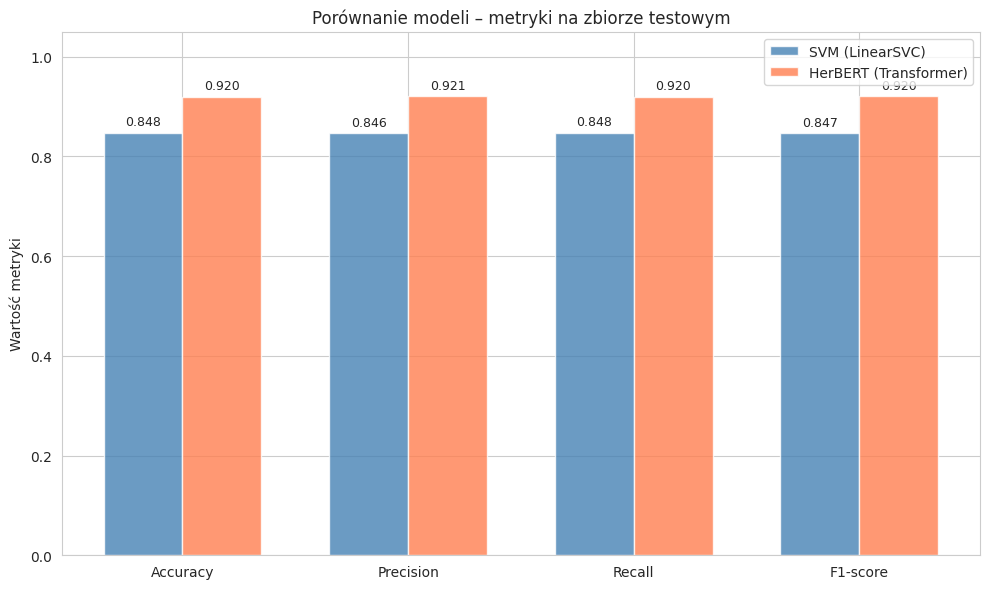

In [4]:
# Wykres porównawczy metryk
metrics_plot = metrics_df.T

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics_plot.index))
width = 0.35

bars1 = ax.bar(
    x - width / 2,
    metrics_plot.iloc[:, 0],
    width,
    label=metrics_plot.columns[0],
    color="steelblue",
    alpha=0.8,
)
bars2 = ax.bar(
    x + width / 2,
    metrics_plot.iloc[:, 1],
    width,
    label=metrics_plot.columns[1],
    color="coral",
    alpha=0.8,
)

ax.set_ylabel("Wartość metryki")
ax.set_title("Porównanie modeli – metryki na zbiorze testowym")
ax.set_xticks(x)
ax.set_xticklabels(metrics_plot.index)
ax.legend()
ax.set_ylim(0, 1.05)

# Wartości nad słupkami
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.3f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

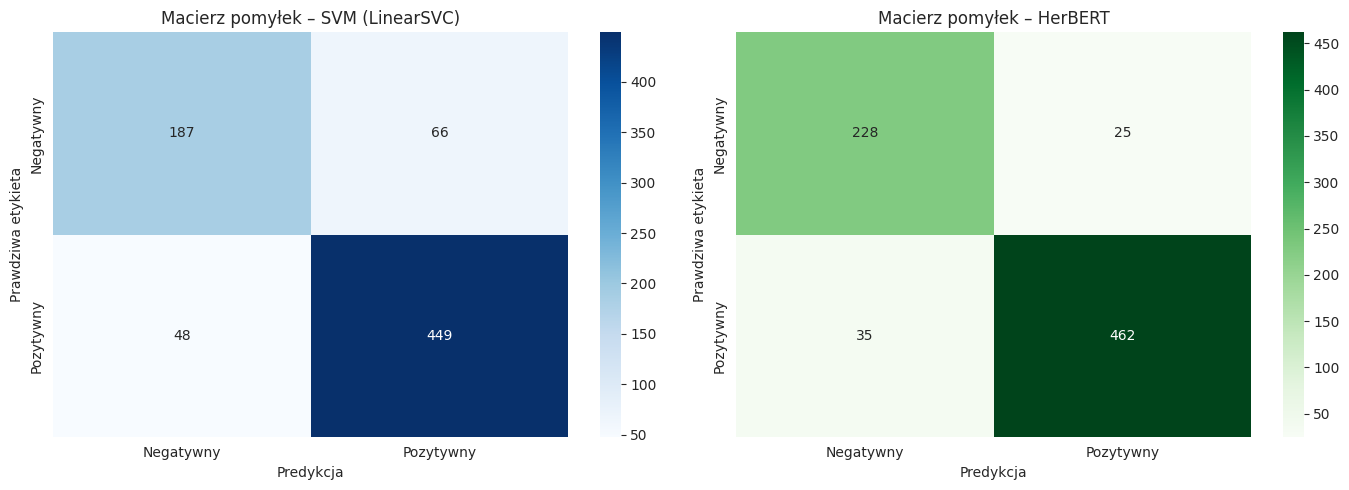

In [5]:
# Macierze pomyłek obok siebie
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, y_pred, cmap) in enumerate([
    (summary["classic_name"], y_pred_classic, "Blues"),
    ("HerBERT", y_pred_transformer, "Greens"),
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        ax=axes[idx],
        xticklabels=["Negatywny", "Pozytywny"],
        yticklabels=["Negatywny", "Pozytywny"],
    )
    axes[idx].set_title(f"Macierz pomyłek – {name}")
    axes[idx].set_xlabel("Predykcja")
    axes[idx].set_ylabel("Prawdziwa etykieta")

plt.tight_layout()
plt.show()

In [6]:
# Szczegółowe raporty klasyfikacji
print(f"{'='*60}")
print(f"Raport klasyfikacji – {summary['classic_name']}")
print(f"{'='*60}")
print(classification_report(
    y_true, y_pred_classic, target_names=["Negatywny", "Pozytywny"]
))

print(f"\n{'='*60}")
print(f"Raport klasyfikacji – HerBERT")
print(f"{'='*60}")
print(classification_report(
    y_true, y_pred_transformer, target_names=["Negatywny", "Pozytywny"]
))

Raport klasyfikacji – SVM (LinearSVC)
              precision    recall  f1-score   support

   Negatywny       0.80      0.74      0.77       253
   Pozytywny       0.87      0.90      0.89       497

    accuracy                           0.85       750
   macro avg       0.83      0.82      0.83       750
weighted avg       0.85      0.85      0.85       750


Raport klasyfikacji – HerBERT
              precision    recall  f1-score   support

   Negatywny       0.87      0.90      0.88       253
   Pozytywny       0.95      0.93      0.94       497

    accuracy                           0.92       750
   macro avg       0.91      0.92      0.91       750
weighted avg       0.92      0.92      0.92       750



## 3. Analiza błędów

In [7]:
# Identyfikacja błędnych predykcji
results_df["classic_correct"] = (y_true == y_pred_classic)
results_df["transformer_correct"] = (y_true == y_pred_transformer)

# Kategorie błędów
results_df["error_type"] = "oba poprawne"
results_df.loc[
    ~results_df["classic_correct"] & results_df["transformer_correct"],
    "error_type"
] = "tylko klasyczny błędny"
results_df.loc[
    results_df["classic_correct"] & ~results_df["transformer_correct"],
    "error_type"
] = "tylko transformer błędny"
results_df.loc[
    ~results_df["classic_correct"] & ~results_df["transformer_correct"],
    "error_type"
] = "oba błędne"

print("Kategorie błędów:")
error_counts = results_df["error_type"].value_counts()
print(error_counts)
print(f"\nProcent zgodności obu modeli: {(error_counts.get('oba poprawne', 0)) / len(results_df) * 100:.1f}%")

Kategorie błędów:
error_type
oba poprawne                604
tylko klasyczny błędny       86
tylko transformer błędny     32
oba błędne                   28
Name: count, dtype: int64

Procent zgodności obu modeli: 80.5%


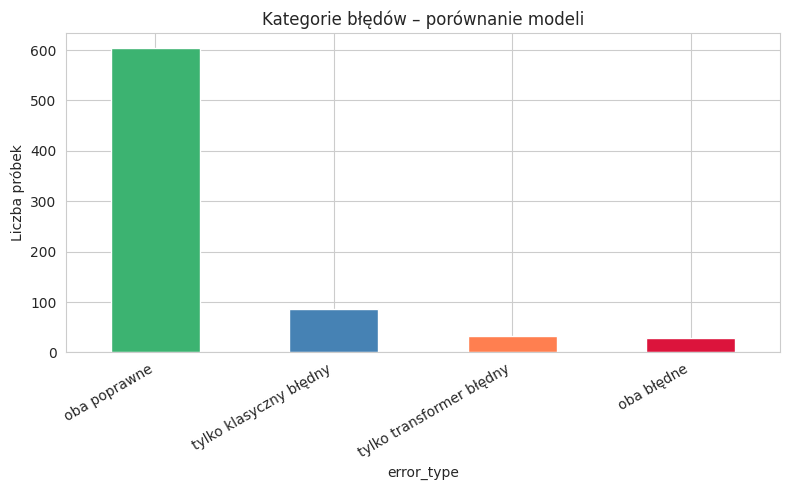

In [8]:
# Wykres kategorii błędów
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["mediumseagreen", "steelblue", "coral", "crimson"]
error_counts.plot(kind="bar", color=colors[:len(error_counts)], ax=ax)
ax.set_title("Kategorie błędów – porównanie modeli")
ax.set_ylabel("Liczba próbek")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [9]:
# Przykłady błędnych predykcji – podejście klasyczne
print("PRZYKŁADY BŁĘDNYCH PREDYKCJI – Podejście klasyczne")
print("=" * 70)

classic_errors = results_df[~results_df["classic_correct"]].head(5)

for _, row in classic_errors.iterrows():
    text = str(row[TEXT_COL])[:200]
    true_label = "Pozytywny" if row[LABEL_COL] == 1 else "Negatywny"
    pred_label = "Pozytywny" if row["pred_classic"] == 1 else "Negatywny"
    print(f"\nTekst: {text}...")
    print(f"  Prawda: {true_label} | Predykcja: {pred_label}")
    print("-" * 70)

PRZYKŁADY BŁĘDNYCH PREDYKCJI – Podejście klasyczne

Tekst: materiał mopa parowego czyli materiału z frędzelkami dobry. Natomiast mocowanie materiału to urąga bezpieczeństwu. Nie sprawdza sie pod wpływem temperatury pary, odrywa sie taśma przyklejona nie takim...
  Prawda: Negatywny | Predykcja: Pozytywny
----------------------------------------------------------------------

Tekst: Bardzo solidne etiu. idealnie chroni tył jak i ekran, ponieważ wystaje ponad niego o jakieś 2 mm. Mój telefon spadł z impetem z 1.5 metra na ziemię, przywalił samym narożnikiem w beton i żadnego śladu...
  Prawda: Pozytywny | Predykcja: Negatywny
----------------------------------------------------------------------

Tekst: Dźwięk ok, ale kiedy już się je włączy. Problemem jest z włączaniem. Czasem trzeba przytrzymać przycisk sekundę, a innym razem słuchawki włączają się po wyczerpaniu zasobu przekleństw. A mam ich sporo...
  Prawda: Negatywny | Predykcja: Pozytywny
------------------------------------------

In [10]:
# Przykłady błędnych predykcji – Transformer
print("PRZYKŁADY BŁĘDNYCH PREDYKCJI – HerBERT (Transformer)")
print("=" * 70)

transformer_errors = results_df[~results_df["transformer_correct"]].head(5)

for _, row in transformer_errors.iterrows():
    text = str(row[TEXT_COL])[:200]
    true_label = "Pozytywny" if row[LABEL_COL] == 1 else "Negatywny"
    pred_label = "Pozytywny" if row["pred_transformer"] == 1 else "Negatywny"
    print(f"\nTekst: {text}...")
    print(f"  Prawda: {true_label} | Predykcja: {pred_label}")
    print("-" * 70)

PRZYKŁADY BŁĘDNYCH PREDYKCJI – HerBERT (Transformer)

Tekst: materiał mopa parowego czyli materiału z frędzelkami dobry. Natomiast mocowanie materiału to urąga bezpieczeństwu. Nie sprawdza sie pod wpływem temperatury pary, odrywa sie taśma przyklejona nie takim...
  Prawda: Negatywny | Predykcja: Pozytywny
----------------------------------------------------------------------

Tekst: Bardzo solidne etiu. idealnie chroni tył jak i ekran, ponieważ wystaje ponad niego o jakieś 2 mm. Mój telefon spadł z impetem z 1.5 metra na ziemię, przywalił samym narożnikiem w beton i żadnego śladu...
  Prawda: Pozytywny | Predykcja: Negatywny
----------------------------------------------------------------------

Tekst: Antenę mam już 2 miesiące podczas których padał obfity śnieg oraz mocny deszcz i w przeciwieństwie do poprzedniej anteny nie było problemu z odbiorem programów . Poprzednia antena miała już 20 lat , a...
  Prawda: Pozytywny | Predykcja: Negatywny
----------------------------------------

In [11]:
# Przykłady gdzie oba modele się mylą (najtrudniejsze przypadki)
print("NAJTRUDNIEJSZE PRZYPADKI – oba modele błędne")
print("=" * 70)

both_wrong = results_df[results_df["error_type"] == "oba błędne"].head(5)

if len(both_wrong) > 0:
    for _, row in both_wrong.iterrows():
        text = str(row[TEXT_COL])[:200]
        true_label = "Pozytywny" if row[LABEL_COL] == 1 else "Negatywny"
        print(f"\nTekst: {text}...")
        print(f"  Prawdziwa etykieta: {true_label}")
        print("-" * 70)
else:
    print("Brak przypadków, gdzie oba modele się mylą.")

NAJTRUDNIEJSZE PRZYPADKI – oba modele błędne

Tekst: materiał mopa parowego czyli materiału z frędzelkami dobry. Natomiast mocowanie materiału to urąga bezpieczeństwu. Nie sprawdza sie pod wpływem temperatury pary, odrywa sie taśma przyklejona nie takim...
  Prawdziwa etykieta: Negatywny
----------------------------------------------------------------------

Tekst: Bardzo solidne etiu. idealnie chroni tył jak i ekran, ponieważ wystaje ponad niego o jakieś 2 mm. Mój telefon spadł z impetem z 1.5 metra na ziemię, przywalił samym narożnikiem w beton i żadnego śladu...
  Prawdziwa etykieta: Pozytywny
----------------------------------------------------------------------

Tekst: Jedyne co można ocenić na plus w tym szkle, to że dobrze przylega całą powierzchnią do ekranu... I tu się kończą plusy. Czytając poprzednie oceny liczyłem się z tym i świadomie dokonałem zakupu z uwag...
  Prawdziwa etykieta: Negatywny
----------------------------------------------------------------------

Tekst: Pr

Accuracy wg długości tekstu (słowa):
            classic_acc  transformer_acc  count
length_bin                                     
1-10             0.9459           1.0000     37
11-25               NaN              NaN      0
26-50            0.7692           0.9231     13
51-100           0.8273           0.9164    550
100+             0.8814           0.8898    118


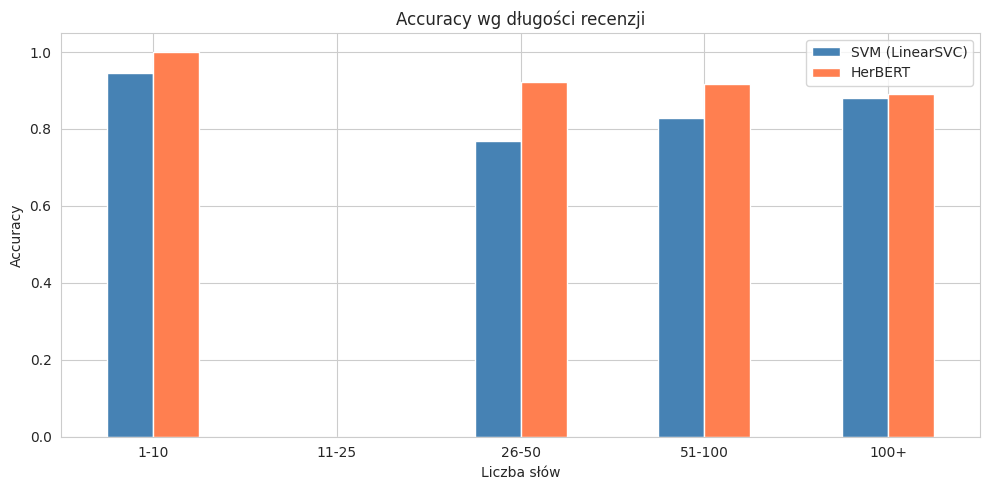

In [12]:
# Analiza błędów wg długości tekstu
results_df["word_count"] = results_df[TEXT_COL].astype(str).apply(lambda x: len(x.split()))

# Binowanie długości
bins = [0, 10, 25, 50, 100, float("inf")]
labels = ["1-10", "11-25", "26-50", "51-100", "100+"]
results_df["length_bin"] = pd.cut(results_df["word_count"], bins=bins, labels=labels)

# Accuracy per bin
acc_by_length = results_df.groupby("length_bin", observed=False).agg(
    classic_acc=("classic_correct", "mean"),
    transformer_acc=("transformer_correct", "mean"),
    count=("classic_correct", "count"),
).round(4)

print("Accuracy wg długości tekstu (słowa):")
print(acc_by_length.to_string())

# Wykres
fig, ax = plt.subplots(figsize=(10, 5))
acc_by_length[["classic_acc", "transformer_acc"]].plot(
    kind="bar", ax=ax, color=["steelblue", "coral"]
)
ax.set_title("Accuracy wg długości recenzji")
ax.set_xlabel("Liczba słów")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.legend([summary["classic_name"], "HerBERT"])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 4. Porównanie jakościowe

In [13]:
# Przypadki gdzie Transformer jest lepszy od klasycznego
print("PRZEWAGA TRANSFORMERA – poprawny Transformer, błędny klasyczny")
print("=" * 70)

transformer_wins = results_df[
    results_df["error_type"] == "tylko klasyczny błędny"
].head(3)

for _, row in transformer_wins.iterrows():
    text = str(row[TEXT_COL])[:250]
    true_label = "Pozytywny" if row[LABEL_COL] == 1 else "Negatywny"
    print(f"\nTekst: {text}...")
    print(f"  Prawda: {true_label}")
    print("-" * 70)

print(f"\n\nPRZEWAGA KLASYCZNEGO – poprawny klasyczny, błędny Transformer")
print("=" * 70)

classic_wins = results_df[
    results_df["error_type"] == "tylko transformer błędny"
].head(3)

for _, row in classic_wins.iterrows():
    text = str(row[TEXT_COL])[:250]
    true_label = "Pozytywny" if row[LABEL_COL] == 1 else "Negatywny"
    print(f"\nTekst: {text}...")
    print(f"  Prawda: {true_label}")
    print("-" * 70)

PRZEWAGA TRANSFORMERA – poprawny Transformer, błędny klasyczny

Tekst: Dźwięk ok, ale kiedy już się je włączy. Problemem jest z włączaniem. Czasem trzeba przytrzymać przycisk sekundę, a innym razem słuchawki włączają się po wyczerpaniu zasobu przekleństw. A mam ich sporo. Ponieważ robię to często, wrażenie jest jak najb...
  Prawda: Negatywny
----------------------------------------------------------------------

Tekst: Do tej pory używałam filtrów Britta oraz Aqaphor i woda przez nie filtrowana trochę się różniła, ale była smaczna, a filtrowanie litra wody chwilę trwało. Filtry Dafi kupiłam ze względu na ich niską cenę pierwszy, ale  chyba ostatni raz. Woda przez f...
  Prawda: Negatywny
----------------------------------------------------------------------

Tekst: Jest to już moje trzecie etui tej marki. Jest bardzo wygodne, przekonał mnie ten pasek - dobrze trzyma smartfon podczas oglądania youtube oraz jak i w stanie zamkniętym. Kolory są wyraziste i wzór chociaż często nie jest ta

## 5. Wnioski

In [14]:
# Podsumowanie wyników
print("\n" + "=" * 60)
print("PODSUMOWANIE PROJEKTU")
print("=" * 60)
print(f"\nZadanie: Analiza sentymentu polskich recenzji produktów (Allegro)")
print(f"Zbiór danych: allegro-reviews (Hugging Face Datasets)")
print(f"Próbki testowe: {len(results_df)}")
print(f"\n{'Model':<30} {'Accuracy':>10} {'F1-score':>10}")
print("-" * 52)
print(f"{summary['classic_name']:<30} {summary['classic_accuracy']:>10.4f} {summary['classic_f1']:>10.4f}")
print(f"{'HerBERT (Transformer)':<30} {summary['transformer_accuracy']:>10.4f} {summary['transformer_f1']:>10.4f}")
print("-" * 52)

diff_acc = summary['transformer_accuracy'] - summary['classic_accuracy']
diff_f1 = summary['transformer_f1'] - summary['classic_f1']
print(f"{'Różnica (T - K)':<30} {diff_acc:>+10.4f} {diff_f1:>+10.4f}")


PODSUMOWANIE PROJEKTU

Zadanie: Analiza sentymentu polskich recenzji produktów (Allegro)
Zbiór danych: allegro-reviews (Hugging Face Datasets)
Próbki testowe: 750

Model                            Accuracy   F1-score
----------------------------------------------------
SVM (LinearSVC)                    0.8480     0.8465
HerBERT (Transformer)              0.9200     0.9204
----------------------------------------------------
Różnica (T - K)                   +0.0720    +0.0738


## Wnioski końcowe

### Porównanie podejść

**Podejście klasyczne (TF-IDF + SVM/NB):**
- Szybki trening i inferencja
- Nie wymaga GPU
- Dobrze radzi sobie z recenzjami zawierającymi wyraźne słowa kluczowe
- Problemy z ironią, sarkazmem, negacjami

**Podejście Transformer (HerBERT):**
- Lepsze rozumienie kontekstu i niuansów językowych
- Wymaga GPU i więcej pamięci
- Dłuższy czas treningu
- Lepsze wyniki na trudnych przypadkach

### Typowe błędy modeli
- Recenzje mieszane (pozytywne i negatywne elementy)
- Ironia i sarkazm
- Krótkie, mało informacyjne recenzje
- Recenzje z wieloma negacjami

### Możliwe ulepszenia
- Więcej epok treningu dla Transformera
- Augmentacja danych
- Ensemble obu podejść
- Użycie większego modelu (np. Polish RoBERTa)